# EPL Match Result Prediction

This notebook trains five machine learning classifiers for English Premier League match result prediction and saves separate PNG figures for each output chart.

**Models:** KNN, Logistic Regression, Naive Bayes, SVM, Neural Network.


In [1]:
import numpy as np
import pandas as pd
import warnings
import os

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

RND = 42
P = "/home/owais-saeed/python/epl_data/Datasets/"
OUT = "/home/owais-saeed/python/ML/EPL/"
FIG = OUT + "figures/"

os.makedirs(OUT, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

Datasets = [
    "2000-01.csv", "2001-02.csv", "2002-03.csv", "2003-04.csv", "2004-05.csv",
    "2005-06.csv", "2006-07.csv", "2007-08.csv", "2008-09.csv", "2009-10.csv",
    "2010-11.csv", "2011-12.csv", "2012-13.csv", "2013-14.csv", "2014-15.csv",
    "2015-16.csv", "2016-17.csv", "2017-18.csv", "2018-19.csv", "2019-20.csv"
]

## 1. Load Dataset and Recover 3-Class Labels

In [2]:
P = "/content/"
df = pd.read_csv(P + "final_dataset.csv", index_col=0)

raw = pd.concat(
    [
        pd.read_csv(P + f, encoding="latin-1")[["Date", "HomeTeam", "AwayTeam", "FTR"]]
        for f in Datasets
    ],
    ignore_index=True
)

raw = raw.drop_duplicates(["Date", "HomeTeam", "AwayTeam"])
key = raw.set_index(["Date", "HomeTeam", "AwayTeam"])["FTR"]

df["FTR3"] = df.set_index(["Date", "HomeTeam", "AwayTeam"]).index.map(key)

assert df["FTR3"].isna().sum() == 0, "label recovery incomplete"
assert ((df["FTR3"] == "H") == (df["FTR"] == "H")).all()

print("Dataset shape:", df.shape)
print("Labels:", df["FTR3"].value_counts().to_dict())

Dataset shape: (6840, 40)
Labels: {'H': 3176, 'A': 1913, 'D': 1751}


## 2. Feature Engineering

In [3]:
form_map = {"W": 3, "D": 1, "L": 0, "M": 0}

for c in ["HM1", "HM2", "HM3", "HM4", "HM5", "AM1", "AM2", "AM3", "AM4", "AM5"]:
    df[c] = df[c].map(form_map)

for c, nc in [
    ("HTP", "HTP_n"),
    ("ATP", "ATP_n"),
    ("HTGD", "HTGD_n"),
    ("ATGD", "ATGD_n"),
    ("DiffPts", "DiffPts_n"),
    ("DiffFormPts", "DiffFormPts_n")
]:
    df[nc] = df[c] / df["MW"]

base_feats = [
    "HTGS", "ATGS", "HTGC", "ATGC", "HTP_n", "ATP_n",
    "HM1", "HM2", "HM3", "HM4", "HM5", "AM1", "AM2", "AM3", "AM4", "AM5",
    "HTFormPts", "ATFormPts", "HTWinStreak3", "HTWinStreak5", "HTLossStreak3",
    "HTLossStreak5", "ATWinStreak3", "ATWinStreak5", "ATLossStreak3", "ATLossStreak5",
    "HTGD_n", "ATGD_n", "DiffPts_n", "DiffFormPts_n"
]

y = df["FTR3"]
XA = df[base_feats].astype(float)

print("Number of features:", len(base_feats))

Number of features: 30


## 3. Bet365 Odds Predictor

In [4]:
odds = pd.concat(
    [
        pd.read_csv(P + f, encoding="latin-1")[["Date", "HomeTeam", "AwayTeam", "B365H", "B365D", "B365A"]]
        for f in ["2015-16.csv", "2016-17.csv", "2017-18.csv"]
    ],
    ignore_index=True
)

inv = 1 / odds[["B365H", "B365D", "B365A"]]
ssum = inv.sum(axis=1)

odds["pH"] = inv["B365H"] / ssum
odds["pD"] = inv["B365D"] / ssum
odds["pA"] = inv["B365A"] / ssum

ok = odds.set_index(["Date", "HomeTeam", "AwayTeam"])[["pH", "pD", "pA"]]
idx = df.set_index(["Date", "HomeTeam", "AwayTeam"]).index

for col in ["pH", "pD", "pA"]:
    df[col] = idx.map(ok[col]).astype(float)

## 4. Train/Test Split and Model Training

In [5]:
def make_models():
    return {
        "KNN (k=25)": KNeighborsClassifier(n_neighbors=25),
        "LogisticRegression": LogisticRegression(max_iter=3000, random_state=RND),
        "Naive Bayes": GaussianNB(),
        "SVM (RBF)": SVC(kernel="rbf", gamma="scale", random_state=RND),
        "Neural Network": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=800,
            alpha=1e-3,
            random_state=RND
        ),
    }

def run(Xtr, ytr, Xte, yte):
    scaler = StandardScaler().fit(Xtr)
    Xtr_scaled = scaler.transform(Xtr)
    Xte_scaled = scaler.transform(Xte)
    out = {}

    for name, clf in make_models().items():
        clf.fit(Xtr_scaled, ytr)
        pred = clf.predict(Xte_scaled)
        out[name] = (
            accuracy_score(yte, pred),
            f1_score(yte, pred, average="macro"),
            pred
        )
    return out

# Original split used in your code/output
# Train: earlier rows, Test: rows from index 5700 onward
test_mask = df.index >= 5700
train_mask = ~test_mask

rA = run(XA[train_mask], y[train_mask], XA[test_mask], y[test_mask])

print("Class distribution test:", y[test_mask].value_counts().to_dict())
print("Majority baseline predict H:", f"{(y[test_mask] == 'H').mean():.4f}")

print(f"""
{'Classifier':<22}{'Accuracy':>10}{'MacroF1':>10}""")
for n in make_models():
    print(f"{n:<22}{rA[n][0]:>10.4f}{rA[n][1]:>10.4f}")

best = max(rA, key=lambda k: rA[k][0])
print(f"""
Best trained classifier: {best}""")
print("Accuracy:", round(rA[best][0], 4))
print("Macro F1:", round(rA[best][1], 4))

Class distribution test: {'H': 517, 'A': 333, 'D': 290}
Majority baseline predict H: 0.4535

Classifier              Accuracy   MacroF1
KNN (k=25)                0.4974    0.4191
LogisticRegression        0.5123    0.3744
Naive Bayes               0.4956    0.3927
SVM (RBF)                 0.5158    0.3767
Neural Network            0.4289    0.3965

Best trained classifier: SVM (RBF)
Accuracy: 0.5158
Macro F1: 0.3767


## 5. Bet365 Test-Only Result

In [6]:
odds_test = df.loc[test_mask, ["pH", "pD", "pA"]]
have_odds = odds_test.notna().all(axis=1)

omap = {"pH": "H", "pD": "D", "pA": "A"}
odds_pred = odds_test[have_odds].idxmax(axis=1).map(omap)

odds_acc = accuracy_score(y[test_mask][have_odds], odds_pred)
odds_f1 = f1_score(y[test_mask][have_odds], odds_pred, average="macro")

print(f"Bet365 odds-implied predictor: acc={odds_acc:.4f}, macroF1={odds_f1:.4f}")

Bet365 odds-implied predictor: acc=0.5456, macroF1=0.4044


## 6. Save Result CSV Files

In [7]:
global_results = pd.DataFrame(
    [
        {"Classifier": n, "Accuracy": rA[n][0], "MacroF1": rA[n][1]}
        for n in make_models()
    ]
    + [
        {"Classifier": "Bet365 odds (test-only)", "Accuracy": odds_acc, "MacroF1": odds_f1}
    ]
)

global_results.to_csv(OUT + "results_global_3way.csv", index=False)
print(global_results)
print("Saved:", OUT + "results_global_3way.csv")

                Classifier  Accuracy   MacroF1
0               KNN (k=25)  0.497368  0.419150
1       LogisticRegression  0.512281  0.374380
2              Naive Bayes  0.495614  0.392749
3                SVM (RBF)  0.515789  0.376687
4           Neural Network  0.428947  0.396456
5  Bet365 odds (test-only)  0.545614  0.404410
Saved: /home/owais-saeed/python/ML/EPL/results_global_3way.csv


## 7. Per-Season Evaluation

In [8]:
mm = df.Date.str[3:5].astype(int)
yy = df.Date.str[-2:].astype(int)
df["Season"] = np.where(mm >= 7, 2000 + yy, 2000 + yy - 1)

rows = []
for s in sorted(df.Season.unique()):
    sub = df[df.Season == s]

    if len(sub) < 200:
        continue

    Xs = sub[base_feats].astype(float)
    ys = sub["FTR3"]

    cut = int(len(sub) * 0.8)
    res = run(Xs.iloc[:cut], ys.iloc[:cut], Xs.iloc[cut:], ys.iloc[cut:])
    bm = max(res, key=lambda k: res[k][0])

    rows.append((s, bm, res[bm][0], np.mean([res[k][0] for k in res])))

pr = pd.DataFrame(rows, columns=["Season", "Best model", "Best acc", "Mean acc(5)"])
pr.to_csv(OUT + "results_per_season_3way.csv", index=False)

print(pr.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("""
Avg best-model acc across seasons:""", round(pr["Best acc"].mean(), 4))
print("Avg 5-classifier mean acc:", round(pr["Mean acc(5)"].mean(), 4))
print("Saved:", OUT + "results_per_season_3way.csv")

 Season         Best model  Best acc  Mean acc(5)
   2000         KNN (k=25)    0.4868       0.4474
   2001 LogisticRegression    0.6316       0.5105
   2002         KNN (k=25)    0.5789       0.5105
   2003         KNN (k=25)    0.4474       0.4184
   2004 LogisticRegression    0.5000       0.4395
   2005 LogisticRegression    0.6316       0.5658
   2006 LogisticRegression    0.4868       0.3974
   2007          SVM (RBF)    0.5526       0.4974
   2008         KNN (k=25)    0.6184       0.5079
   2009 LogisticRegression    0.5921       0.4921
   2010 LogisticRegression    0.5658       0.4132
   2011         KNN (k=25)    0.5132       0.4395
   2012 LogisticRegression    0.5395       0.4211
   2013          SVM (RBF)    0.5921       0.5579
   2014          SVM (RBF)    0.4868       0.4342
   2015          SVM (RBF)    0.4737       0.3684
   2016         KNN (k=25)    0.5921       0.5342
   2017          SVM (RBF)    0.4868       0.4263

Avg best-model acc across seasons: 0.5431
Avg 5-c

## 8. Prepare Reports for Plots

In [9]:
model_names = list(make_models().keys())
short_names = {
    "KNN (k=25)": "KNN",
    "LogisticRegression": "Logistic Regression",
    "Naive Bayes": "Naive Bayes",
    "SVM (RBF)": "SVM",
    "Neural Network": "Neural Network"
}

class_labels = ["A", "D", "H"]
class_names = ["Away Win", "Draw", "Home Win"]

reports = {}
for name in model_names:
    reports[name] = classification_report(
        y[test_mask],
        rA[name][2],
        labels=class_labels,
        output_dict=True,
        zero_division=0
    )

metrics_rows = []
f1_rows = []

for name in model_names:
    rep = reports[name]
    metrics_rows.append({
        "Classifier": short_names[name],
        "Precision": rep["macro avg"]["precision"],
        "Recall": rep["macro avg"]["recall"],
        "F1": rep["macro avg"]["f1-score"]
    })
    f1_rows.append({
        "Classifier": short_names[name],
        "Away Win": rep["A"]["f1-score"],
        "Draw": rep["D"]["f1-score"],
        "Home Win": rep["H"]["f1-score"]
    })

metric_df = pd.DataFrame(metrics_rows)
f1_df = pd.DataFrame(f1_rows)

metric_df.to_csv(OUT + "results_precision_recall_f1.csv", index=False)
f1_df.to_csv(OUT + "results_per_class_f1.csv", index=False)

print(metric_df)
print(f1_df)

            Classifier  Precision    Recall        F1
0                  KNN   0.440441  0.433763  0.419150
1  Logistic Regression   0.408911  0.430623  0.374380
2          Naive Bayes   0.406684  0.432118  0.392749
3                  SVM   0.463747  0.428303  0.376687
4       Neural Network   0.397813  0.396298  0.396456
            Classifier  Away Win      Draw  Home Win
0                  KNN  0.455738  0.176611  0.625100
1  Logistic Regression  0.460587  0.013378  0.649175
2          Naive Bayes  0.474483  0.075145  0.628619
3                  SVM  0.446337  0.032895  0.650828
4       Neural Network  0.388715  0.258407  0.542247


## 9. Plot 1: Test Accuracy PNG

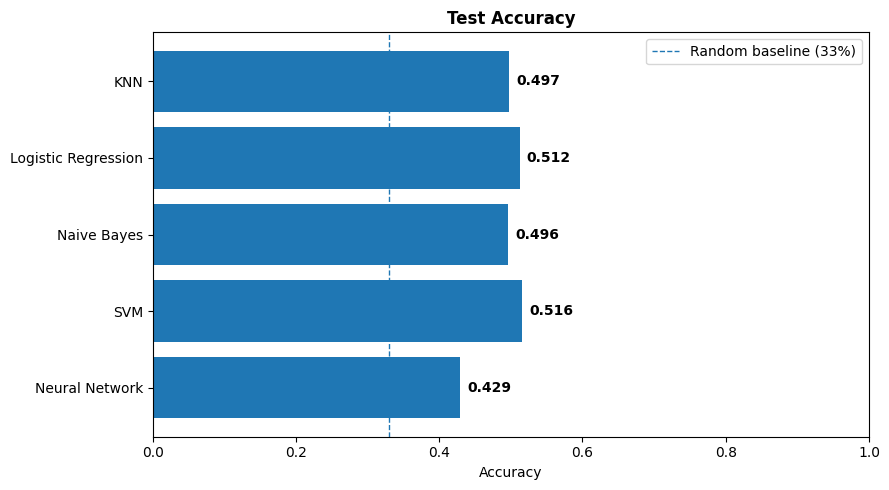

Saved: /home/owais-saeed/python/ML/EPL/figures/01_test_accuracy.png


In [10]:
plot_df = global_results[global_results["Classifier"] != "Bet365 odds (test-only)"].copy()
plot_df["Name"] = plot_df["Classifier"].map(short_names)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Name"], plot_df["Accuracy"])
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Test Accuracy", fontweight="bold")
plt.axvline(0.33, linestyle="--", linewidth=1, label="Random baseline (33%)")
plt.legend()
plt.gca().invert_yaxis()

for i, v in enumerate(plot_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG + "01_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG + "01_test_accuracy.png")

## 10. Plot 2: Confusion Matrix PNG for Each Classifier

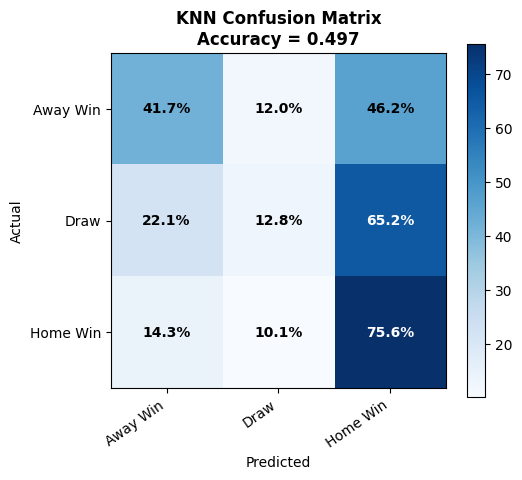

Saved: /home/owais-saeed/python/ML/EPL/figures/02_confusion_matrix_knn.png


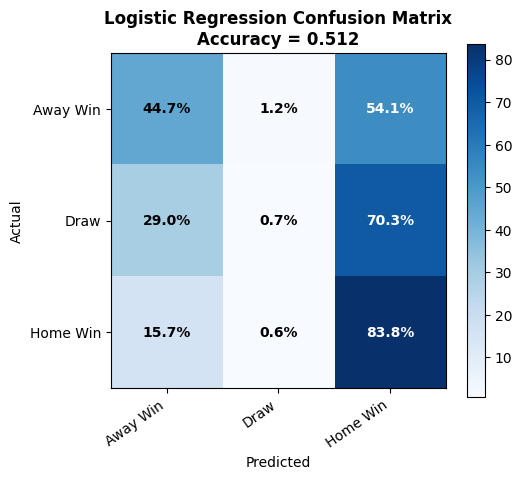

Saved: /home/owais-saeed/python/ML/EPL/figures/02_confusion_matrix_logistic_regression.png


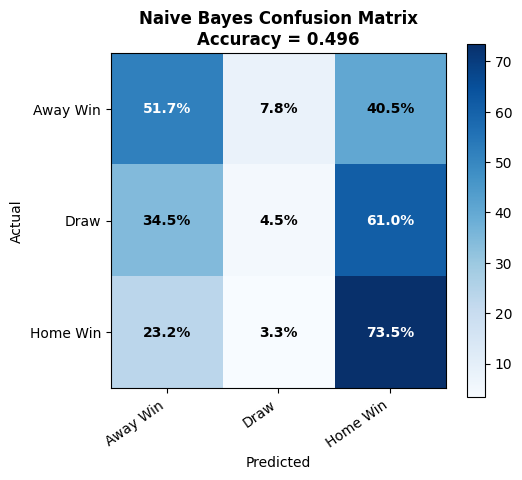

Saved: /home/owais-saeed/python/ML/EPL/figures/02_confusion_matrix_naive_bayes.png


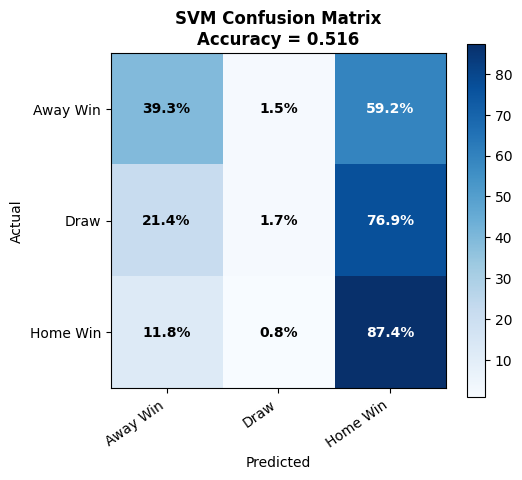

Saved: /home/owais-saeed/python/ML/EPL/figures/02_confusion_matrix_svm.png


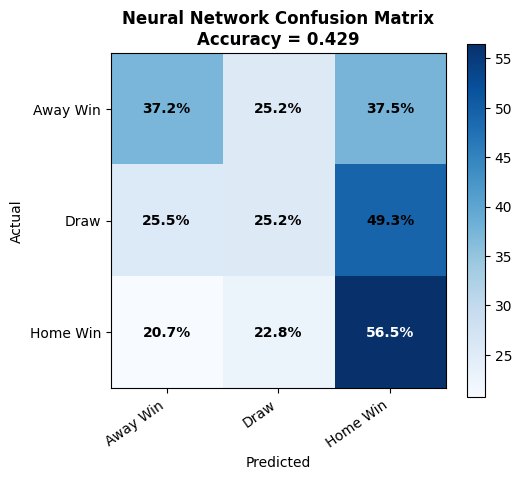

Saved: /home/owais-saeed/python/ML/EPL/figures/02_confusion_matrix_neural_network.png


In [11]:
for name in model_names:
    cm = confusion_matrix(y[test_mask], rA[name][2], labels=class_labels)
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(5.5, 4.8))
    plt.imshow(cm_percent, cmap="Blues")
    plt.title(f"""{short_names[name]} Confusion Matrix
Accuracy = {rA[name][0]:.3f}""", fontweight="bold")
    plt.xticks(range(3), class_names, rotation=35, ha="right")
    plt.yticks(range(3), class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for r in range(3):
        for c in range(3):
            plt.text(
                c,
                r,
                f"{cm_percent[r, c]:.1f}%",
                ha="center",
                va="center",
                fontweight="bold",
                color="white" if cm_percent[r, c] > 50 else "black"
            )

    safe = short_names[name].replace(" ", "_").lower()
    path = FIG + f"02_confusion_matrix_{safe}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 11. Plot 3: Per-Class F1 Score PNG

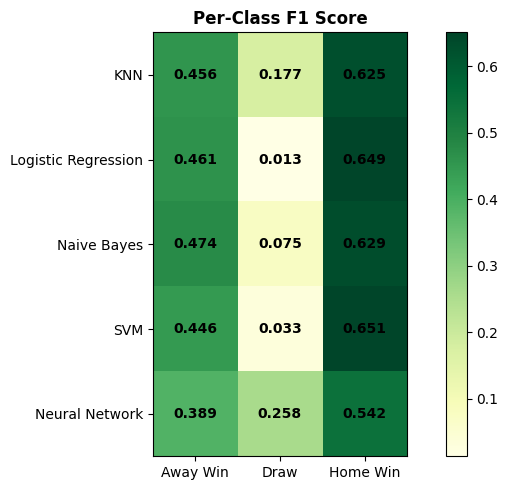

Saved: /home/owais-saeed/python/ML/EPL/figures/03_per_class_f1.png


In [12]:
heat = f1_df[["Away Win", "Draw", "Home Win"]].values

plt.figure(figsize=(8, 5))
plt.imshow(heat, cmap="YlGn")
plt.title("Per-Class F1 Score", fontweight="bold")
plt.xticks(range(3), ["Away Win", "Draw", "Home Win"])
plt.yticks(range(len(f1_df)), f1_df["Classifier"])
plt.colorbar()

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        plt.text(c, r, f"{heat[r, c]:.3f}", ha="center", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG + "03_per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG + "03_per_class_f1.png")

## 12. Plot 4: Precision / Recall / F1 PNG

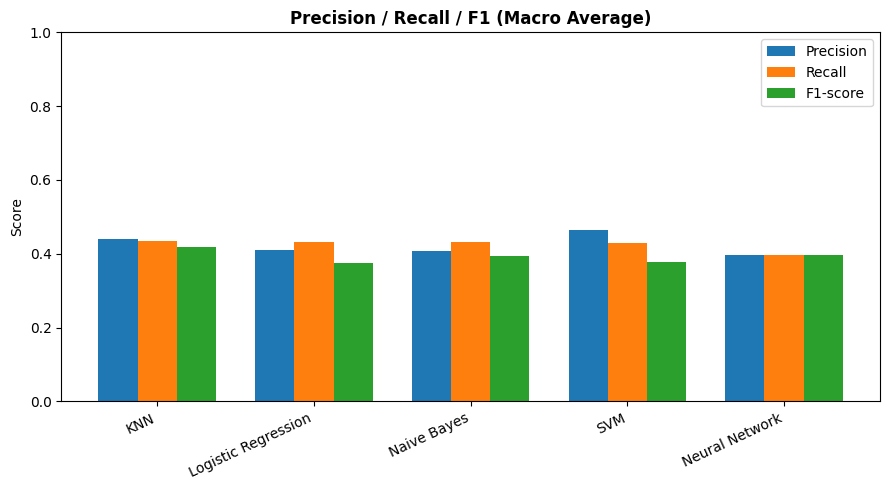

Saved: /home/owais-saeed/python/ML/EPL/figures/04_precision_recall_f1_macro.png


In [13]:
x = np.arange(len(metric_df))
w = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - w, metric_df["Precision"], width=w, label="Precision")
plt.bar(x, metric_df["Recall"], width=w, label="Recall")
plt.bar(x + w, metric_df["F1"], width=w, label="F1-score")

plt.ylim(0, 1)
plt.title("Precision / Recall / F1 (Macro Average)", fontweight="bold")
plt.xticks(x, metric_df["Classifier"], rotation=25, ha="right")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIG + "04_precision_recall_f1_macro.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG + "04_precision_recall_f1_macro.png")

## 13. Plot 5: Result Distribution PNG

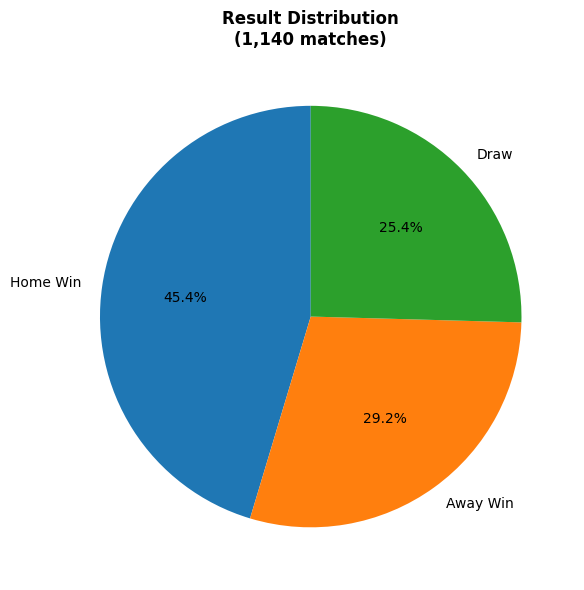

Saved: /home/owais-saeed/python/ML/EPL/figures/05_result_distribution.png


In [14]:
dist = y[test_mask].value_counts()
pie_values = [dist["H"], dist["A"], dist["D"]]
pie_labels = ["Home Win", "Away Win", "Draw"]

plt.figure(figsize=(6, 6))
plt.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90)
plt.title(f"""Result Distribution
({len(y[test_mask]):,} matches)""", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG + "05_result_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG + "05_result_distribution.png")

## 14. Plot 6: Per-Season Accuracy PNG

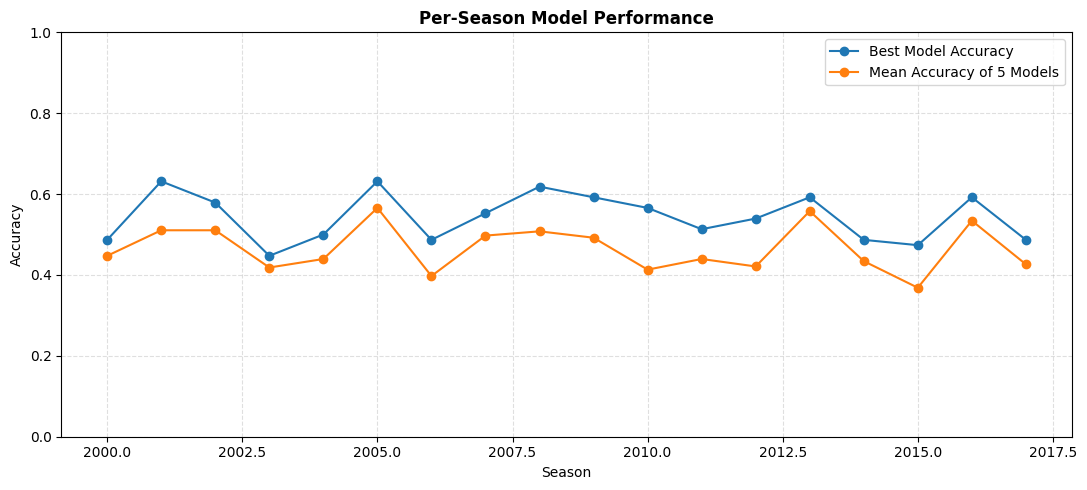

Saved: /home/owais-saeed/python/ML/EPL/figures/06_per_season_accuracy.png


In [15]:
plt.figure(figsize=(11, 5))
plt.plot(pr["Season"], pr["Best acc"], marker="o", label="Best Model Accuracy")
plt.plot(pr["Season"], pr["Mean acc(5)"], marker="o", label="Mean Accuracy of 5 Models")
plt.ylim(0, 1)
plt.xlabel("Season")
plt.ylabel("Accuracy")
plt.title("Per-Season Model Performance", fontweight="bold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG + "06_per_season_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIG + "06_per_season_accuracy.png")

## 15. Final Summary

In [17]:
print("Best classifier:", best)
print(f"Best accuracy: {rA[best][0]:.4f}")
print(f"Best macro F1: {rA[best][1]:.4f}")
print(f"Bet365 accuracy: {odds_acc:.4f}")
print(f"Bet365 macro F1: {odds_f1:.4f}")

Best classifier: SVM (RBF)
Best accuracy: 0.5158
Best macro F1: 0.3767
Bet365 accuracy: 0.5456
Bet365 macro F1: 0.4044
